# 05. Digital Twin Retrospective Replay & Counterfactual Simulation

In this notebook, we utilize the `DigitalTwinState` and `DigitalTwinEngine` backend modules to run a retrospective simulation of a patient's trajectory and perform a what-if analysis.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from backend.digital_twin.models import DigitalTwinState
from backend.digital_twin.engine import DigitalTwinEngine

## 1. Quick Model Prep
We need the trained model and preprocessor to initialize the engine.

In [2]:
data_dir = '../data'
nhanes_files = ['DEMO_J.xpt', 'GHB_J.xpt', 'GLU_J.xpt', 'BIOPRO_J.xpt', 'BMX_J.xpt', 'DIQ_J.xpt', 'PAQ_J.xpt', 'SMQ_J.xpt']
nhanes_df = None
for file in nhanes_files:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        df = pd.read_sas(file_path)
        nhanes_df = df if nhanes_df is None else pd.merge(nhanes_df, df, on='SEQN', how='outer')

nhanes_df = nhanes_df.dropna(subset=['LBXGH'])
y = nhanes_df['LBXGH'].fillna(nhanes_df['LBXGH'].median())
features = ['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'BMXWAIST', 'LBXGLU', 'PAQ605', 'SMQ020']
X = nhanes_df[features].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'LBXGLU']),
    ('cat', cat_transformer, ['RIAGENDR', 'PAQ605', 'SMQ020'])
])

X_train_prep = preprocessor.fit_transform(X_train)
feature_names = (['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'LBXGLU'] +
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['RIAGENDR', 'PAQ605', 'SMQ020'])))

X_train_df = pd.DataFrame(X_train_prep, columns=feature_names)
model = XGBRegressor(n_estimators=50, random_state=42)
model.fit(X_train_df, y_train)

explainer = shap.Explainer(model)
engine = DigitalTwinEngine(model=model, preprocessor=preprocessor, explainer=explainer, feature_names=feature_names)

## 2. Retrospective Digital Twin Replay
We'll simulate a patient whose health parameters (BMI, Glucose, Age) evolve over 4 time steps.

Time 1 | BMI: 28.0 | Fasting Glu: 90.0 | Predicted HbA1c: 5.19
Time 2 | BMI: 30.5 | Fasting Glu: 98.0 | Predicted HbA1c: 5.52
Time 3 | BMI: 33.0 | Fasting Glu: 115.0 | Predicted HbA1c: 5.95
Time 4 | BMI: 29.0 | Fasting Glu: 100.0 | Predicted HbA1c: 5.57


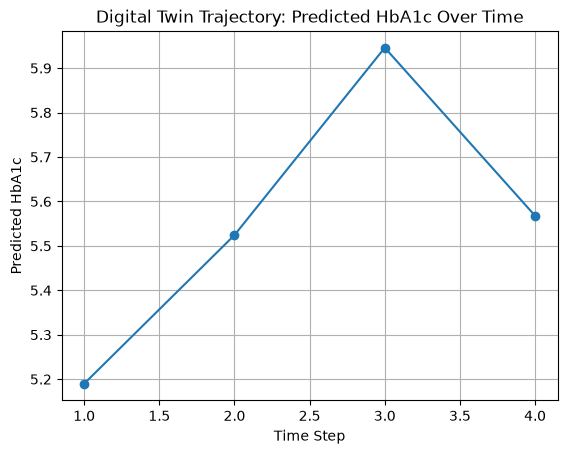

In [3]:
patient_trajectory = [
    {'RIDAGEYR': 45, 'RIAGENDR': 1.0, 'BMXBMI': 28.0, 'BMXWAIST': 95.0, 'LBXGLU': 90.0, 'PAQ605': 2.0, 'SMQ020': 2.0},  # t1: Baseline
    {'RIDAGEYR': 46, 'RIAGENDR': 1.0, 'BMXBMI': 30.5, 'BMXWAIST': 102.0, 'LBXGLU': 98.0, 'PAQ605': 2.0, 'SMQ020': 2.0}, # t2: Weight gain
    {'RIDAGEYR': 47, 'RIAGENDR': 1.0, 'BMXBMI': 33.0, 'BMXWAIST': 108.0, 'LBXGLU': 115.0, 'PAQ605': 2.0, 'SMQ020': 2.0}, # t3: Pre-diabetic
    {'RIDAGEYR': 48, 'RIAGENDR': 1.0, 'BMXBMI': 29.0, 'BMXWAIST': 98.0, 'LBXGLU': 100.0, 'PAQ605': 1.0, 'SMQ020': 2.0}   # t4: Intervention (weight loss + exercise)
]

twin = DigitalTwinState(patient_id="PT_001")

hba1c_trajectory = []
for i, obs in enumerate(patient_trajectory):
    twin = engine.update(twin, obs)
    pred = twin.get_latest_prediction()
    hba1c_trajectory.append(pred.predicted_value)
    print(f"Time {i+1} | BMI: {obs['BMXBMI']} | Fasting Glu: {obs['LBXGLU']} | Predicted HbA1c: {pred.predicted_value:.2f}")

plt.plot([1, 2, 3, 4], hba1c_trajectory, marker='o')
plt.title('Digital Twin Trajectory: Predicted HbA1c Over Time')
plt.xlabel('Time Step')
plt.ylabel('Predicted HbA1c')
plt.grid(True)
plt.show()

## 3. Counterfactual / What-If Simulator
Let's assume the patient is currently at `t3`. What if they exercised vigorously (`PAQ605` = 1.0) and reduced BMI to 25?

In [4]:
# Set current state back to t3 for demonstration
twin = engine.update(twin, patient_trajectory[2])

scenario = engine.simulate(
    twin=twin, 
    scenario_name="Intensive Lifestyle Intervention", 
    modified_vars={'BMXBMI': 25.0, 'PAQ605': 1.0, 'BMXWAIST': 85.0}
)

print("Baseline Prediction (HbA1c):", round(scenario.baseline_prediction, 2))
print("Scenario Prediction (HbA1c):", round(scenario.scenario_prediction, 2))
print("Difference:", round(scenario.prediction_difference, 2))
print("Message:", scenario.message)

Baseline Prediction (HbA1c): 5.95
Scenario Prediction (HbA1c): 5.72
Difference: -0.22
Message: Under the model's learned associations, this simulated scenario is associated with an estimated change of -0.22.
